In [15]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_PATH = os.path.join("..", "data", "raw", "kaggle_dataset_temp.csv")

# Load raw dataset
df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 7308 rows, 7 columns


In [16]:
# Preview first 5 rows
print("--- First 5 Rows ---")
display(df.head())

# Preview last 5 rows
print("--- Last 5 Rows ---")
display(df.tail())

--- First 5 Rows ---


,Date,Location,Rainfall_mm,WaterLevel_m,SoilMoisture_pct,Elevation_m,FloodOccurrence
0,2016-01-01,Quezon City,12.0,0.5,15.3,43,0
1,2016-01-01,Marikina,10.6,1.8,23.2,15,0
2,2016-01-01,Manila,5.7,0.5,15.6,5,0
3,2016-01-01,Pasig,3.7,0.5,5.0,5,0
4,2016-01-02,Quezon City,3.4,0.5,13.3,43,0


--- Last 5 Rows ---


,Date,Location,Rainfall_mm,WaterLevel_m,SoilMoisture_pct,Elevation_m,FloodOccurrence
7303,2020-12-30,Pasig,16.9,1.4,16.8,5,0
7304,2020-12-31,Quezon City,7.2,0.7,25.6,43,0
7305,2020-12-31,Marikina,4.8,1.3,9.6,15,0
7306,2020-12-31,Manila,7.4,1.0,11.9,5,0
7307,2020-12-31,Pasig,7.8,1.5,7.3,5,0


In [17]:
# check column data types, total entries, and non-null counts
print("--- DataFrame Info ---")
df.info()

--- DataFrame Info ---
<class 'pandas.DataFrame'>
RangeIndex: 7308 entries, 0 to 7307
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              7308 non-null   str    
 1   Location          7308 non-null   str    
 2   Rainfall_mm       7308 non-null   float64
 3   WaterLevel_m      7308 non-null   float64
 4   SoilMoisture_pct  7308 non-null   float64
 5   Elevation_m       7308 non-null   int64  
 6   FloodOccurrence   7308 non-null   int64  
dtypes: float64(3), int64(2), str(2)
memory usage: 399.8 KB


In [18]:
# total null values per column
print("--- Missing Values Per Column ---")
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Percentage (%)': missing_percent})
display(missing_df)

# duplicate rows across all columns
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

--- Missing Values Per Column ---


,Missing Count,Percentage (%)
Date,0,0.0
Location,0,0.0
Rainfall_mm,0,0.0
WaterLevel_m,0,0.0
SoilMoisture_pct,0,0.0
Elevation_m,0,0.0
FloodOccurrence,0,0.0


Total duplicate rows: 0


In [19]:
print("--- Numerical Features Summary Statistics ---")
display(df.describe().T)

--- Numerical Features Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
Rainfall_mm,7308.0,10.052874,7.101769,0.1,4.9,8.4,13.5,52.7
WaterLevel_m,7308.0,1.266379,0.902239,0.5,0.5,1.0,1.8,6.4
SoilMoisture_pct,7308.0,15.184989,5.994044,5.0,10.9,14.9,19.1,39.7
Elevation_m,7308.0,17.000000,15.557414,5.0,5.0,10.0,22.0,43.0
FloodOccurrence,7308.0,0.018062,0.133186,0.0,0.0,0.0,0.0,1.0


In [20]:
# group by City to check Elevation statistics (mean, std, min, max)
elevation_check = df.groupby("Location")["Elevation_m"].agg(
    ["count", "min", "max", "mean", "std"]
)
print("--- Elevation Variance by City (checking std = 0) ---")
display(elevation_check)

# explicit boolean check
is_static = (elevation_check["std"] == 0).all()
print(
    f"Formally confirmed: Elevation is a static city-level constant -> {is_static}"
)

--- Elevation Variance by City (checking std = 0) ---


,count,min,max,mean,std
Location,,,,,
Manila,1827,5,5,5.0,0.0
Marikina,1827,15,15,15.0,0.0
Pasig,1827,5,5,5.0,0.0
Quezon City,1827,43,43,43.0,0.0


Formally confirmed: Elevation is a static city-level constant -> True


In [21]:
print("--- Records per City ---")
city_counts = df["Location"].value_counts()
display(city_counts)

print("\n--- FloodOccurrence Distribution (Class Balance) ---")
flood_counts = df["FloodOccurrence"].value_counts()
flood_percent = df["FloodOccurrence"].value_counts(normalize=True) * 100

flood_dist_df = pd.DataFrame({"Count": flood_counts, "Percentage (%)": flood_percent})
display(flood_dist_df)

--- Records per City ---


Location
Quezon City    1827
Marikina       1827
Manila         1827
Pasig          1827
Name: count, dtype: int64


--- FloodOccurrence Distribution (Class Balance) ---


,Count,Percentage (%)
FloodOccurrence,,
0,7176,98.19376
1,132,1.80624


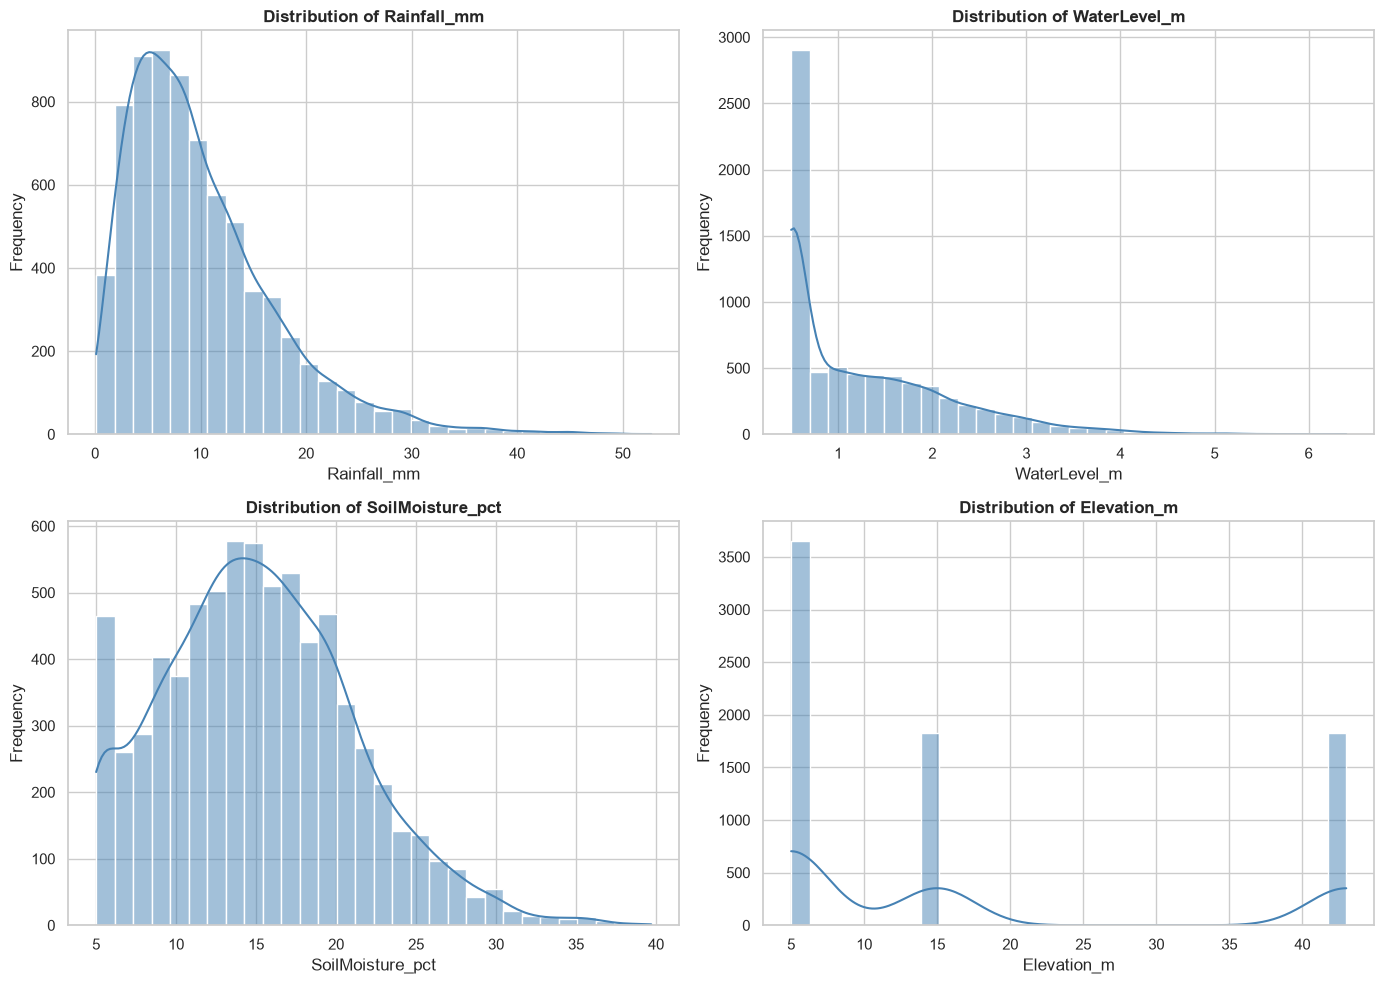

In [22]:
# identifying numeric predictor columns (rainfall, river water level, soil moisture were continuous predictors; elevation as static city-level numeric predictor)
numeric_cols = ["Rainfall_mm", "WaterLevel_m", "SoilMoisture_pct", "Elevation_m"]

# subplot grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[idx], color="steelblue", bins=30)
    axes[idx].set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

C:\Users\My PC\AppData\Local\Temp\ipykernel_15764\981571615.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\My PC\AppData\Local\Temp\ipykernel_15764\981571615.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="FloodOccurrence", ax=axes[1], palette="coolwarm")
C:\Users\My PC\AppData\Local\Temp\ipykernel_15764\981571615.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["No Flood (0)", "Flood (1)"])


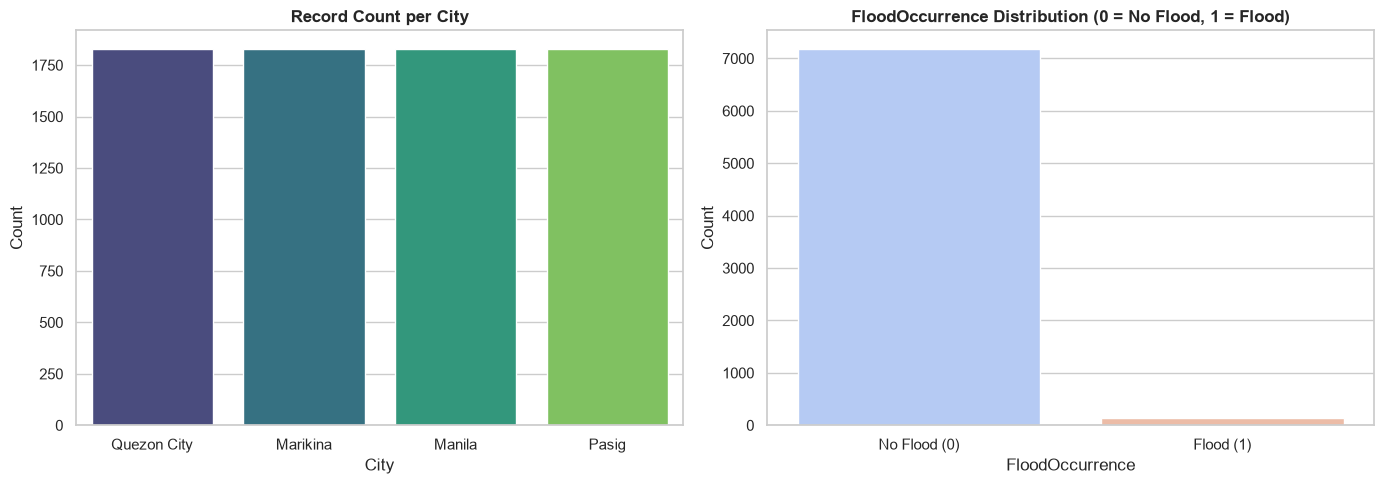

In [23]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# plot records per city
sns.countplot(
    data=df,
    x="Location",
    ax=axes[0],
    palette="viridis",
    order=df["Location"].value_counts().index,
)
axes[0].set_title("Record Count per City", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("City")

# plot FloodOccurrence class distribution
sns.countplot(data=df, x="FloodOccurrence", ax=axes[1], palette="coolwarm")
axes[1].set_title(
    "FloodOccurrence Distribution (0 = No Flood, 1 = Flood)",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_ylabel("Count")
axes[1].set_xlabel("FloodOccurrence")
axes[1].set_xticklabels(["No Flood (0)", "Flood (1)"])

plt.tight_layout()
plt.show()

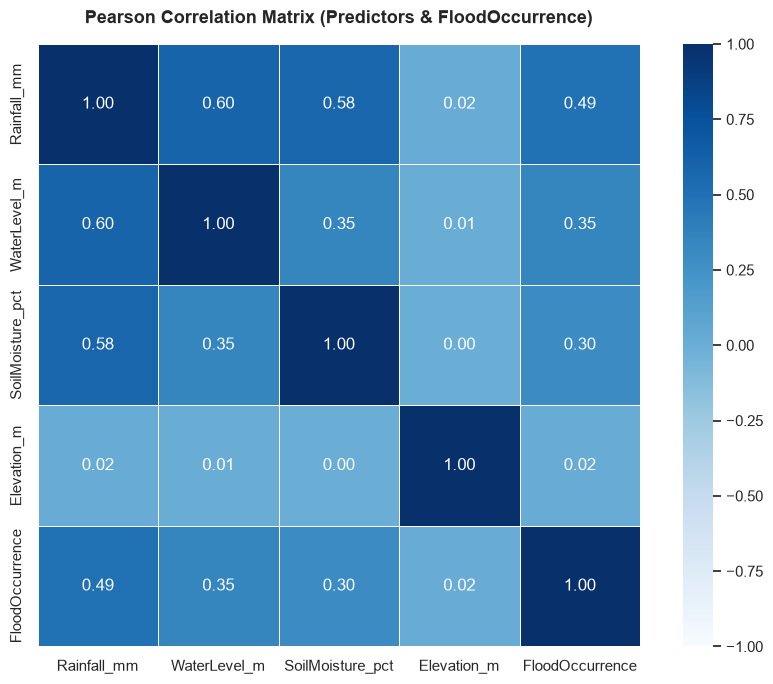

--- Correlation with FloodOccurrence ---


FloodOccurrence     1.000000
Rainfall_mm         0.494940
WaterLevel_m        0.349567
SoilMoisture_pct    0.296241
Elevation_m         0.019418
Name: FloodOccurrence, dtype: float64

In [24]:
# correlation analysis
corr_cols = ["Rainfall_mm", "WaterLevel_m", "SoilMoisture_pct", "Elevation_m", "FloodOccurrence",]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=-1,
    vmax=1,
    cbar=True,
    square=True,
    linewidths=0.5,
)
plt.title(
    "Pearson Correlation Matrix (Predictors & FloodOccurrence)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()

# raw correlation values with FloodOccurrence
print("--- Correlation with FloodOccurrence ---")
display(corr_matrix["FloodOccurrence"].sort_values(ascending=False))

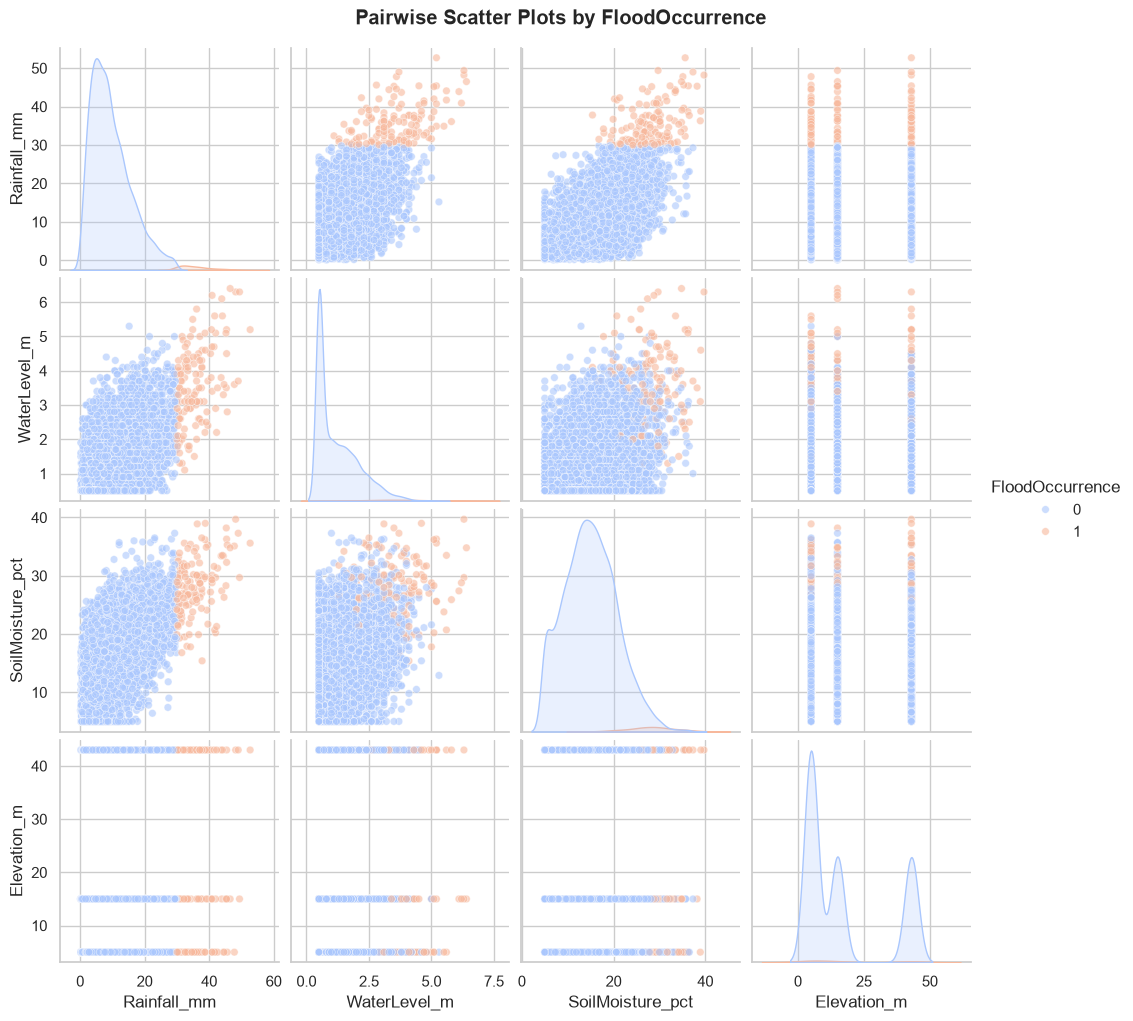

In [25]:
# pairwise relationship inspection
pairplot_fig = sns.pairplot(
    df,
    vars=["Rainfall_mm", "WaterLevel_m", "SoilMoisture_pct", "Elevation_m"],
    hue="FloodOccurrence",
    palette="coolwarm",
    diag_kind="kde",
    plot_kws={"alpha": 0.6, "s": 30},
)
pairplot_fig.fig.suptitle(
    "Pairwise Scatter Plots by FloodOccurrence", y=1.02, fontweight="bold"
)
plt.show()

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# prepare feature matrix with continuous variables and one-hot encoded city columns
vif_df_input = df[
    ["Rainfall_mm", "WaterLevel_m", "SoilMoisture_pct", "Elevation_m"]
].copy()
city_dummies = pd.get_dummies(
    df["Location"], prefix="Loc", drop_first=True, dtype=float
)
vif_features = pd.concat([vif_df_input, city_dummies], axis=1)

# add intercept constant (required for standard VIF computation)
vif_features.insert(0, "const", 1.0)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = vif_features.columns
vif_data["VIF"] = [
    variance_inflation_factor(vif_features.values, i)
    for i in range(vif_features.shape[1])
]

print("--- Variance Inflation Factor (VIF) Table ---")
display(vif_data.sort_values(by="VIF", ascending=False))

--- Variance Inflation Factor (VIF) Table ---


C:\Users\My PC\AppData\Local\Temp\ipykernel_15764\3700954774.py:19: UserWarning: The design matrix is poorly conditioned (condition number=2.05e+15). VIF calculations may be numerically unstable.
  variance_inflation_factor(vif_features.values, i)
c:\Users\My PC\OneDrive\Desktop\flood-risk-system\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\Users\My PC\OneDrive\Desktop\flood-risk-system\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\Users\My PC\OneDrive\Desktop\flood-risk-system\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquel

,Feature,VIF
5,Loc_Marikina,1.000800e+15
7,Loc_Quezon City,1.000800e+15
4,Elevation_m,1.000800e+15
1,Rainfall_mm,2.057592e+00
2,WaterLevel_m,1.556262e+00
3,SoilMoisture_pct,1.506860e+00
6,Loc_Pasig,1.500444e+00
0,const,1.000000e+00


## Exploratory Data Analysis Summary & Key Observations

### 1. Dataset Structure & Quality
- Evaluated raw daily historical data across four study cities: Manila, Marikina, Quezon City, and Pasig (2016–2020).
- Verified data types, total record counts, missing/null values, and duplicate records. Each city contains 1,827 daily records (7,308 total), with zero missing values or duplicate records identified.

### 2. Feature Distributions, Predictor Relationships & Collinearity
- **Predictors ($X$):** Rainfall_mm, RiverWaterLevel_m, SoilMoisture_pct, Elevation_m, and Location (categorical).
- **Distributions:** Rainfall and River Water Level are right-skewed (concentrated at lower values with extreme peak events). Soil Moisture exhibits a centralized distribution. Elevation exists as 4 discrete values.
- **Static Feature Verification:** Grouping by `City` confirms zero variance (`std = 0.0`) for Elevation within each city, formally proving it is a static, city-level constant rather than a dynamic daily variable.
- **Multicollinearity & VIF:** Including one-hot encoded City dummies alongside continuous features yields near-infinite/extreme VIF for Elevation, confirming perfect linear dependency between Elevation and City categories.
- **Model Justification:** Inter-feature correlations and non-linear threshold dynamics motivate comparing CART-based models (Decision Trees) against linear baselines.

### 3. Target & Class Imbalance
- `FloodOccurrence` shows a pronounced minority positive class (flood events) relative to non-flood days.
- Motivates using `class_weight='balanced'` for tree classifiers and prioritizing Recall and F1-score over raw Accuracy during evaluation.

### 4. Modeling Constraints & Target Leakage Prevention
- `FloodOccurrence` will **not** be used as an input predictor to avoid target leakage.
- The eventual regression target is `FloodDepth_m` (temporarily held by Rainfall as a placeholder), and the classification target is `RiskLevel` (derived using official MGB susceptibility thresholds).